Background: The client has recently taken over operations of a Retail Distribution Warehouse for a three-month transitional period. Given the recent acquisition, internal familiarity with warehouse operations and outbound process controls remains limited.

Objective:  To identify the bottleneck in inbounc operations, and implement corrective measures to stabilize throughput and close the fulfillment gap.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
Inbound = pd.read_excel('Inbound2.xlsx')
Inbound.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Outlet     357 non-null    object
 1   Date       357 non-null    int64 
 2   SKUlink    357 non-null    int64 
 3   SKUnumber  357 non-null    int64 
 4   Item Desc  357 non-null    object
 5   GR Qty     357 non-null    int64 
dtypes: int64(4), object(2)
memory usage: 16.9+ KB


In [3]:
MasterData = pd.read_excel('Master Data R1.xlsx')
MasterData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 189 entries, 0 to 188
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SKUlink        189 non-null    int64  
 1   SKUnumber      189 non-null    int64  
 2   Category       189 non-null    object 
 3   Item Desc      189 non-null    object 
 4   UOM            189 non-null    object 
 5   ctn conv       189 non-null    int64  
 6   Hi             189 non-null    int64  
 7   Ti             189 non-null    int64  
 8   pallet conv    189 non-null    int64  
 9   Avg UnitPrice  189 non-null    float64
dtypes: float64(1), int64(6), object(3)
memory usage: 14.9+ KB


In [4]:
Inbound = Inbound.merge(MasterData, on=['SKUlink', 'SKUnumber', 'Item Desc'], how='left')
Inbound.reset_index(drop=True, inplace=True)
Inbound.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Outlet         357 non-null    object 
 1   Date           357 non-null    int64  
 2   SKUlink        357 non-null    int64  
 3   SKUnumber      357 non-null    int64  
 4   Item Desc      357 non-null    object 
 5   GR Qty         357 non-null    int64  
 6   Category       357 non-null    object 
 7   UOM            357 non-null    object 
 8   ctn conv       357 non-null    int64  
 9   Hi             357 non-null    int64  
 10  Ti             357 non-null    int64  
 11  pallet conv    357 non-null    int64  
 12  Avg UnitPrice  357 non-null    float64
dtypes: float64(1), int64(8), object(4)
memory usage: 36.4+ KB


In [5]:
Inbound['Total Unit'] = np.where(
    Inbound['UOM'] == 'carton',
    Inbound['GR Qty'] * Inbound['ctn conv'],
    Inbound['GR Qty'])
Inbound['Pallets'] = np.where(
    (Inbound['Total Unit'] / Inbound['ctn conv'] / Inbound['pallet conv']) > 1,
    np.floor(Inbound['Total Unit'] / Inbound['ctn conv'] / Inbound['pallet conv']),
    0)
Inbound['Cartons'] = np.where(
    ((Inbound['Total Unit'] - Inbound['Pallets'] * Inbound['ctn conv'] * Inbound['pallet conv']) / Inbound['ctn conv']) > 1,
    np.floor((Inbound['Total Unit'] - Inbound['Pallets'] * Inbound['ctn conv'] * Inbound['pallet conv']) / Inbound['ctn conv']),
    0)
Inbound['Units'] = np.where(
    (Inbound['Total Unit'] - (Inbound['Pallets'] * Inbound['ctn conv'] * Inbound['pallet conv']) - (Inbound['Cartons'] * Inbound['ctn conv'])) > 1,
    Inbound['Total Unit'] - (Inbound['Pallets'] * Inbound['ctn conv'] * Inbound['pallet conv']) - (Inbound['Cartons'] * Inbound['ctn conv']),
    0)
Inbound.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Outlet         357 non-null    object 
 1   Date           357 non-null    int64  
 2   SKUlink        357 non-null    int64  
 3   SKUnumber      357 non-null    int64  
 4   Item Desc      357 non-null    object 
 5   GR Qty         357 non-null    int64  
 6   Category       357 non-null    object 
 7   UOM            357 non-null    object 
 8   ctn conv       357 non-null    int64  
 9   Hi             357 non-null    int64  
 10  Ti             357 non-null    int64  
 11  pallet conv    357 non-null    int64  
 12  Avg UnitPrice  357 non-null    float64
 13  Total Unit     357 non-null    int64  
 14  Pallets        357 non-null    float64
 15  Cartons        357 non-null    float64
 16  Units          357 non-null    float64
dtypes: float64(4), int64(9), object(4)
memory usage: 47.5+

In [6]:
Inbound['Pallets'] = np.where(
    (Inbound['Total Unit'] / Inbound['ctn conv'] / Inbound['pallet conv']) > 1,
    np.floor(Inbound['Total Unit'] / Inbound['ctn conv'] / Inbound['pallet conv']),
    0)
Inbound['Cartons'] = np.where(
    ((Inbound['Total Unit'] - Inbound['Pallets'] * Inbound['ctn conv'] * Inbound['pallet conv']) / Inbound['ctn conv']) > 1,
    np.floor((Inbound['Total Unit'] - Inbound['Pallets'] * Inbound['ctn conv'] * Inbound['pallet conv']) / Inbound['ctn conv']),
    0)
Inbound['Units'] = np.where(
    (Inbound['Total Unit'] - (Inbound['Pallets'] * Inbound['ctn conv'] * Inbound['pallet conv']) - (Inbound['Cartons'] * Inbound['ctn conv'])) > 1,
    Inbound['Total Unit'] - (Inbound['Pallets'] * Inbound['ctn conv'] * Inbound['pallet conv']) - (Inbound['Cartons'] * Inbound['ctn conv']),
    0)
Inbound.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Outlet         357 non-null    object 
 1   Date           357 non-null    int64  
 2   SKUlink        357 non-null    int64  
 3   SKUnumber      357 non-null    int64  
 4   Item Desc      357 non-null    object 
 5   GR Qty         357 non-null    int64  
 6   Category       357 non-null    object 
 7   UOM            357 non-null    object 
 8   ctn conv       357 non-null    int64  
 9   Hi             357 non-null    int64  
 10  Ti             357 non-null    int64  
 11  pallet conv    357 non-null    int64  
 12  Avg UnitPrice  357 non-null    float64
 13  Total Unit     357 non-null    int64  
 14  Pallets        357 non-null    float64
 15  Cartons        357 non-null    float64
 16  Units          357 non-null    float64
dtypes: float64(4), int64(9), object(4)
memory usage: 47.5+

In [7]:
filtered_df = Inbound[(Inbound['Cartons'] >= 1) & (Inbound['Pallets'] >= 1)]
filtered_df

,Outlet,Date,SKUlink,SKUnumber,Item Desc,GR Qty,Category,UOM,ctn conv,Hi,Ti,pallet conv,Avg UnitPrice,Total Unit,Pallets,Cartons,Units
2,FDC,20230728,100104,100104,Item 000104,800,GROCERY,unit,12,5,11,55,1.66,800,1.0,11.0,8.0
23,FDC,20230718,100100,100100,Item 000100,1200,GROCERY,unit,24,6,8,48,5.14,1200,1.0,2.0,0.0
128,FDC,20230707,100104,100104,Item 000104,800,GROCERY,unit,12,5,11,55,1.66,800,1.0,11.0,8.0
142,FDC,20230627,100100,100100,Item 000100,1600,GROCERY,unit,24,6,8,48,5.14,1600,1.0,18.0,16.0
165,FDC,20230621,100157,100157,Item 000157,2000,GOURMET USE,unit,4,4,9,36,27.93,2000,13.0,32.0,0.0
224,FDC,20230619,100168,100168,Item 000168,1824,GROCERY,unit,24,7,10,70,1.09,1824,1.0,6.0,0.0
225,FDC,20230619,100167,100167,Item 000167,768,GROCERY,unit,12,5,11,55,1.70,768,1.0,9.0,0.0
226,FDC,20230614,100008,100008,Item 000008,624,GOURMET USE,unit,12,5,10,50,6.55,624,1.0,2.0,0.0
227,FDC,20230614,100010,100010,Item 000010,800,GOURMET USE,unit,4,4,9,36,28.20,800,5.0,20.0,0.0
279,FDC,20230529,100155,100155,Item 000155,720,GOURMET USE,unit,12,5,10,50,6.47,720,1.0,10.0,0.0


In [8]:
filtered_df = Inbound[(Inbound['Units'] >= 1) & (Inbound['Cartons'] >= 1) & (Inbound['Pallets'] >= 1)]
filtered_df

,Outlet,Date,SKUlink,SKUnumber,Item Desc,GR Qty,Category,UOM,ctn conv,Hi,Ti,pallet conv,Avg UnitPrice,Total Unit,Pallets,Cartons,Units
2,FDC,20230728,100104,100104,Item 000104,800,GROCERY,unit,12,5,11,55,1.66,800,1.0,11.0,8.0
128,FDC,20230707,100104,100104,Item 000104,800,GROCERY,unit,12,5,11,55,1.66,800,1.0,11.0,8.0
142,FDC,20230627,100100,100100,Item 000100,1600,GROCERY,unit,24,6,8,48,5.14,1600,1.0,18.0,16.0


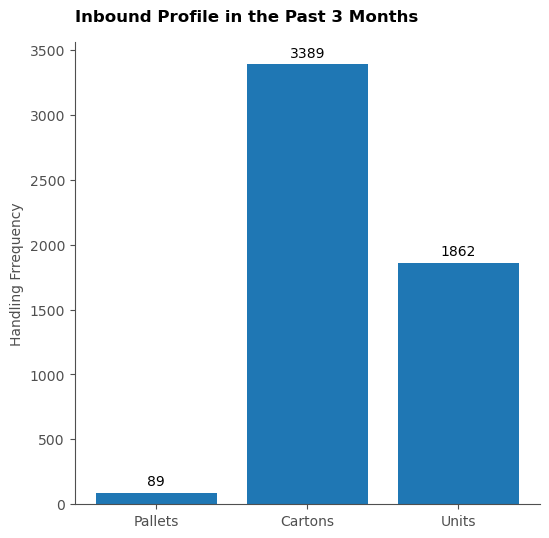

In [9]:
total_pallets = Inbound['Pallets'].sum()
total_cartons = Inbound['Cartons'].sum()
total_units = Inbound['Units'].sum()

InboundProfile = pd.DataFrame({'Inbound Profile': ['Pallets', 'Cartons', 'Units'],
                               'Total': [total_pallets, total_cartons, total_units]})

fig, ax = plt.subplots(figsize=(6, 6))
bars = ax.bar(InboundProfile['Inbound Profile'], InboundProfile['Total'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#4F4F4F')
ax.spines['bottom'].set_color('#4F4F4F')
ax.tick_params(axis='x', colors='#4F4F4F')
ax.tick_params(axis='y', colors='#4F4F4F')
ax.set_ylabel('Handling Frrequency', color='#4F4F4F')
ax.set_title('Inbound Profile in the Past 3 Months', pad=15, loc='left', fontweight='bold')
ax.bar_label(bars, padding=3)
plt.show()

- Observation: Cartons (3,389) and Units (1,862) significantly surpass Pallets (89) handling requirements.
- Bottleneck: The current operation is optimized for "Full Pallet" flows, however, approximately 98% of inbound activiy consists of "Loose" flows.
- Insight: The bottleneck driven by every carton and unit requires manual sorting and individual processing, which creates a disproportionate labor requirement compared to the volume of pallets.
- Suggestion: To improve efficiency, the operation model must transition from pallet inbound process to one designed specifically for loose item handling.

In [10]:
Inbound['Pallet Mod'] = (Inbound['Total Unit'] / Inbound['ctn conv'] / Inbound['pallet conv'].round(1)) % 1
Inbound['Pallets2'] = np.where((Inbound['Pallet Mod']) >= 0.7, Inbound['Pallets']+1, Inbound['Pallets'])
Inbound.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Outlet         357 non-null    object 
 1   Date           357 non-null    int64  
 2   SKUlink        357 non-null    int64  
 3   SKUnumber      357 non-null    int64  
 4   Item Desc      357 non-null    object 
 5   GR Qty         357 non-null    int64  
 6   Category       357 non-null    object 
 7   UOM            357 non-null    object 
 8   ctn conv       357 non-null    int64  
 9   Hi             357 non-null    int64  
 10  Ti             357 non-null    int64  
 11  pallet conv    357 non-null    int64  
 12  Avg UnitPrice  357 non-null    float64
 13  Total Unit     357 non-null    int64  
 14  Pallets        357 non-null    float64
 15  Cartons        357 non-null    float64
 16  Units          357 non-null    float64
 17  Pallet Mod     357 non-null    float64
 18  Pallets2  

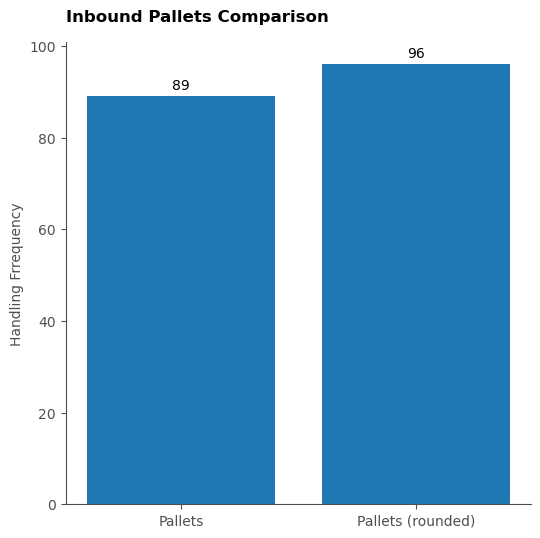

In [11]:
total_pallets = Inbound['Pallets'].sum()
total_pallets2 = Inbound['Pallets2'].sum()

InboundProfile = pd.DataFrame({'Inbound Profile': ['Pallets', 'Pallets (rounded)'],
                               'Total': [total_pallets, total_pallets2]})

fig, ax = plt.subplots(figsize=(6, 6))
bars = ax.bar(InboundProfile['Inbound Profile'], InboundProfile['Total'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#4F4F4F')
ax.spines['bottom'].set_color('#4F4F4F')
ax.tick_params(axis='x', colors='#4F4F4F')
ax.tick_params(axis='y', colors='#4F4F4F')
ax.set_ylabel('Handling Frrequency', color='#4F4F4F')
ax.set_title('Inbound Pallets Comparison', pad=15, loc='left', fontweight='bold')
ax.bar_label(bars, padding=3)
plt.show()

- Observation: Rounding up pallet quantities to the nearest half-pallet increment yielded a negligible increase in total pallet count (from 89 to 96). This confirms that current inbound volumes are significantly below full-pallet thresholds across the majority of the SKU profile.
- Bottleneck: The primary operational bottleneck is not the number of pallets, but the handling frequency of loose cargo. With 3,389 cartons and 1,862 units compared to only 89 pallets, the labour requirement is dominated by manual sorting and individual item processing.
- Insight: The high ratio of loose cartons or units indicates a mature Just-In-Time (JIT) inventory strategy. 
- Suggestion: The client should keep their JIT model as it serves their inventory goals. However, the receiving process must be changed to handle loose cargo more efficiently.

Key Takeaways:
1. Infrastructure mismatch: The facility is physically designed for "Pallet-in", but the business model is actually "Carton-in / Unit-in". This is the root cause of the fulfillment gap.
2. A 3-month transitional operation faced throughput instability. To mitigate this, a quarterly operational audit must be implemented to ensure that handling processes and labour allocation stay sychronized with the inventory requirements and SKU profiles.